# Desafio 1

In [1]:
import pandas as pd
url_hospedagens = "https://raw.githubusercontent.com/alura-cursos/data-science-regressao-linear/main/dados/hospedagens.csv"

df = pd.read_csv(url_hospedagens)

In [6]:
df.head()

,valor,area,dist_praia,dist_mercado,piscina
0,4600.0,280,0.241,0.794,1
1,900.0,208,0.904,0.134,1
2,2550.0,170,0.060,0.423,1
3,550.0,100,2.883,0.525,0
4,2200.0,164,0.240,0.192,0


In [4]:
print(df.shape)
df.info()

(5000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   valor         5000 non-null   float64
 1   area          5000 non-null   int64  
 2   dist_praia    5000 non-null   float64
 3   dist_mercado  5000 non-null   float64
 4   piscina       5000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 195.4 KB


In [3]:
# Matriz de correlação
corr = df.corr()
corr

,valor,area,dist_praia,dist_mercado,piscina
valor,1.000000,0.710974,-0.366543,-0.024377,0.294870
area,0.710974,1.000000,-0.283372,-0.030997,0.299858
dist_praia,-0.366543,-0.283372,1.000000,0.025650,-0.322888
dist_mercado,-0.024377,-0.030997,0.025650,1.000000,-0.004902
piscina,0.294870,0.299858,-0.322888,-0.004902,1.000000


In [5]:
corr['valor'].to_frame()

# area -> variável com maior influência no preço
# dist_praia -> Quanto menor a distância da praia, maior o valor do imóvel
# dist_mercado -> Parece que não existe uma relação pois o valor é de -0.024377
# piscina -> Imóveis com piscina tendem a ser mais caros, mas a relação não é tão determinante quanto a área

,valor
valor,1.000000
area,0.710974
dist_praia,-0.366543
dist_mercado,-0.024377
piscina,0.294870


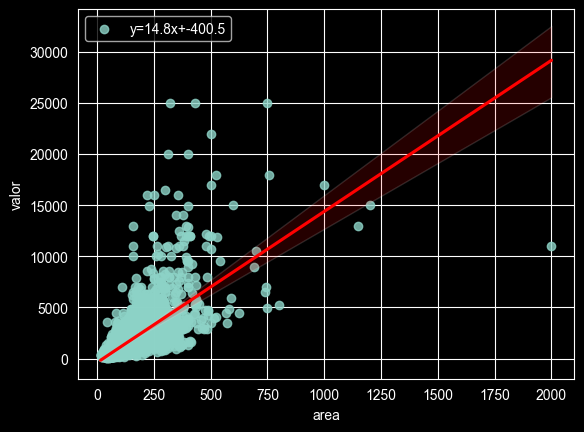

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
slope, intercept, rvalue, pvalue, stderr = stats.linregress(df['area'], df['valor'])

sns.regplot(x='area', y='valor', data=df, line_kws={'color':'red'}, label=f"y={slope:.1f}x+{intercept:.1f}").legend(loc="best")
plt.show()


# Desafio 2

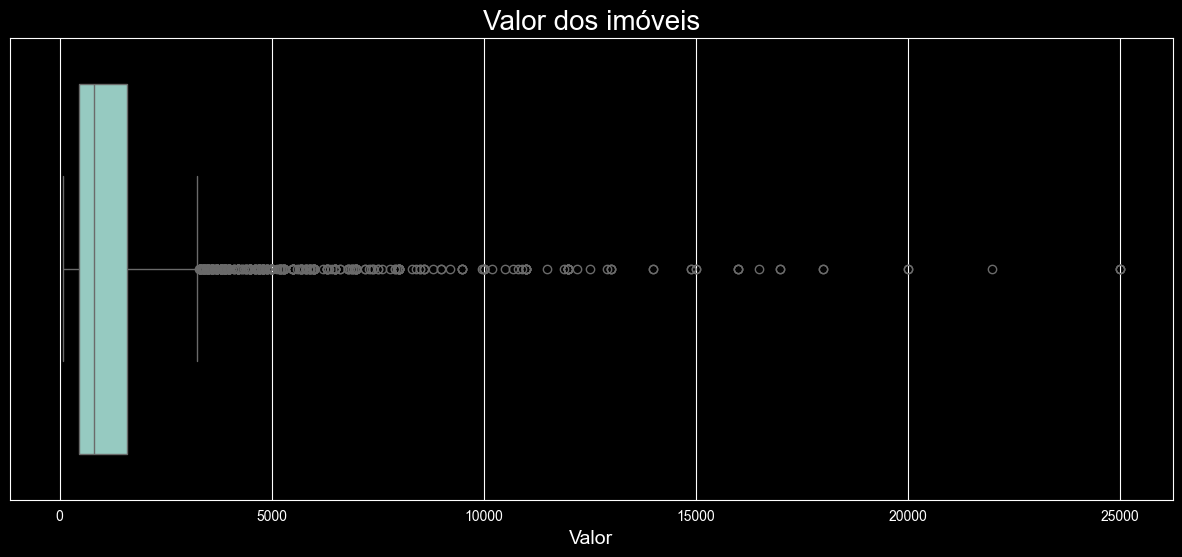

In [17]:
ax = sns.boxplot(data=df, x='valor')
ax.figure.set_size_inches(15, 6)
ax.set_title('Valor dos imóveis', fontsize=20)
ax.set_xlabel('Valor', fontsize=14)
plt.show();

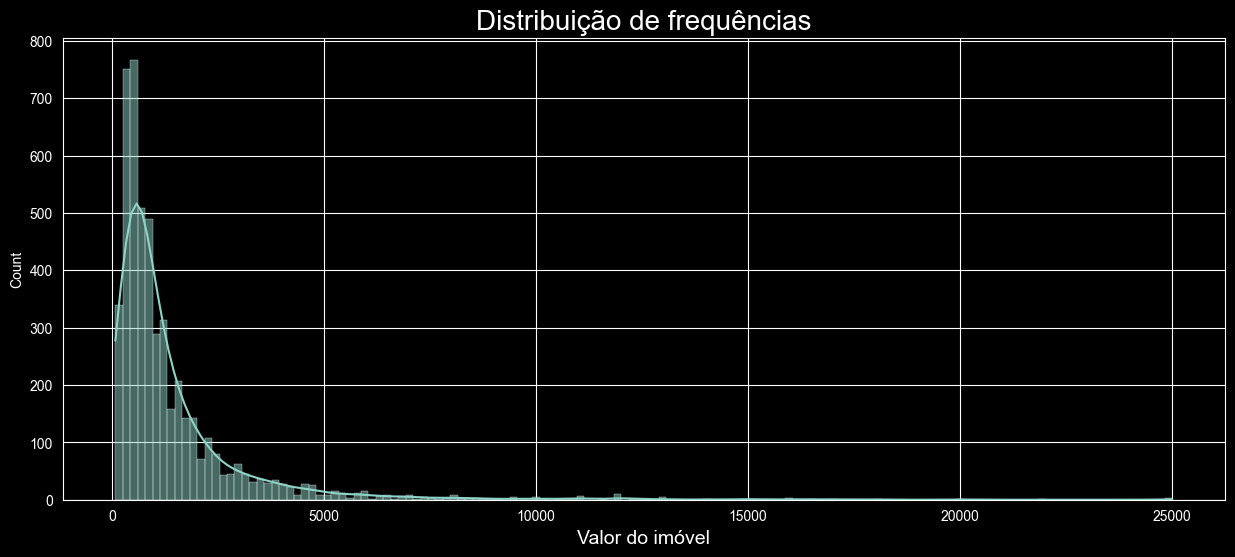

In [12]:
ax = sns.histplot(data=df, x='valor', kde=True)
ax.figure.set_size_inches(15, 6)
ax.set_title('Distribuição de frequências', fontsize=20)
ax.set_xlabel('Valor do imóvel', fontsize=14)
plt.show();

In [14]:
df.columns

Index(['valor', 'area', 'dist_praia', 'dist_mercado', 'piscina'], dtype='object')

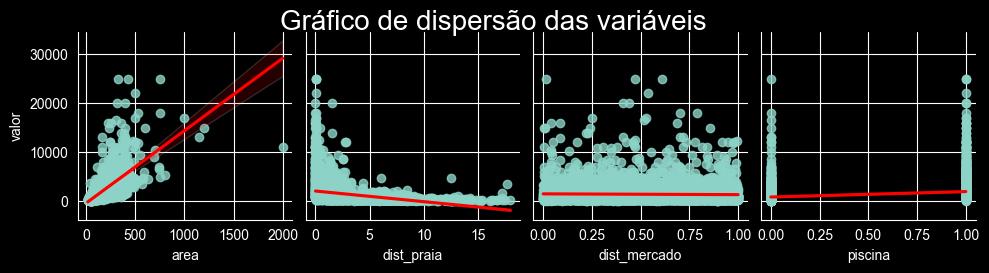

In [15]:
ax = sns.pairplot(data=df, y_vars='valor', x_vars=['area', 'dist_praia', 'dist_mercado', 'piscina'], kind='reg', plot_kws={'line_kws': {'color': 'red'}})
ax.figure.suptitle('Gráfico de dispersão das variáveis', fontsize=20, y=1.05)
plt.show()